# Оценка привлекательности ПИФов

# Введение

Паевые инвестиционные фонды (ПИФы) представляют собой механизм коллективного инвестирования, при котором средства вкладчиков объединяются и передаются под управление профессиональной компании. Управляющая компания формирует фонд, распределяя капитал между различными активами, такими как акции, облигации, недвижимость или драгоценные металлы. Весь инвестиционный портфель делится на доли - паи, которые распределяются между инвесторами в соответствии с их вложениями и дают им право на соответствующую часть фонда.

Мы решили рассмотреть ПИФы, предлагаемые УК “Первая”.
УК Первая - одна из ведущих управляющих компаний на российском рынке, специализирующаяся на управлении активами, №1 по объему рынка БПИФ
и ОПИФ в 2024 году.

<img src="https://i.ibb.co/N26Jp0cC/image3.png" alt="image3" border="0">

### Фонд Накопительный

В рамках данного исследования рассматривается открытый паевой инвестиционный фонд (ОПИФ) рыночных финансовых инструментов “Фонд Накопительный”. Этот фонд был создан в декабре 2017 года и ориентирован на получение дохода от вложений в денежный рынок, а также в облигации с фиксированным и плавающим купоном. Основные инвестиционные активы фонда включают депозиты крупнейших российских банков, государственные и корпоративные облигации.
Фонд особенно актуален в условиях жесткой денежно-кредитной политики, поскольку его стратегия позволяет извлекать выгоду из высоких ставок на денежном рынке. Инструмент подходит инвесторам, стремящимся сохранить капитал и получать умеренный доход при относительно низком уровне риска.
Фонд имеет минимальный риск-рейтинг по шкале, используемой УК Первая, - 1 из 7. Ликвидность - средняя (можно выйти из продукта без существенных потерь), рекомендуемый срок инвестирования - от 6 месяцев.

<img src="https://i.ibb.co/ymgp1Dqf/image3.png" alt="image3" border="0">

<img src="https://i.ibb.co/Mxd7dfhD/image7.png" alt="image7" border="0">

<img src="https://i.ibb.co/kVjs0tsY/image8.png" alt="image8" border="0">

### Фонд российских акций

Открытый паевой инвестиционный фонд (ОПИФ) «Фонд российских акций» под управлением УК «Первая» был основан в июне 1997 года. Он ориентирован на долгосрочное инвестирование в акции российских компаний, обладающих высокой ликвидностью и потенциалом роста. Некоторая доля активов фонда также представлена акциями второго эшелона.
Фонд показывает значительный рост на длинном инвестиционном горизонте. За последние 10 лет его доходность составила 163,7%, а за 5 лет – 23,5%. Однако его высокая ориентированность на рынок акций делает инструмент достаточно волатильным.
Риск-профиль фонда высокий: максимальное снижение стоимости пая за 10 лет составило -57,1%, а волатильность – 23,4%. Коэффициент Шарпа, измеряющий доходность на единицу риска, составляет -0,47, что указывает на высокие колебания доходности. Риск-рейтинг - 5 из 7.

<img src="https://i.ibb.co/QFmgPGPp/image1.png" alt="image1" border="0">

<img src="https://i.ibb.co/G4KV6QNH/image4.png" alt="image4" border="0">

<img src="https://i.ibb.co/hJT7phxH/image10.png" alt="image10" border="0">

### Фонд сбалансированный

Фонд нацелен на получение дохода в рублях за счет инвестирования в акции и облигации преимущественно российских эмитентов для обеспечения баланса между приемлемым уровнем риска и ожидаемой доходностью. Активы фонда инвестированы в диверсифицированный портфель акций и облигаций. Стратегия фонда основывается на динамичном распределении средств между классами активов (акциями и облигациями).
<img src="https://i.ibb.co/HpfBxjgm/image2.png" alt="image2" border="0">

<img src="https://i.ibb.co/v6vRNpFy/image6.png" alt="image6" border="0">

<img src="https://i.ibb.co/rKkJX4vv/image5.png" alt="image5" border="0">

# Библиотеки и файлы

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import prophet as _prophet
import seaborn as sns
from prophet import Prophet

warnings.filterwarnings("ignore")

# Прогноз строится библиотекой prophet поверх встроенной (предкомпилированной)
# модели cmdstan. В linux-колесе prophet каталог cmdstan идёт «урезанным» — без
# файла makefile, из-за чего cmdstanpy отказывается принимать путь. Сама модель
# уже собрана (prophet_model.bin), компиляция не нужна, поэтому достаточно создать
# пустой makefile, чтобы пройти валидацию пути.
_cmdstan = pathlib.Path(_prophet.__file__).parent / "stan_model" / "cmdstan-2.33.1"
_makefile = _cmdstan / "makefile"
if _cmdstan.exists() and not _makefile.exists():
    _makefile.touch()

In [2]:
# Единый tidy-датасет, собранный из исходных .xlsx (см. scripts/merge_data.py).
# Колонки: date, fund, fund_type (open/closed), price, nav, income.
funds = pd.read_csv("data/funds.csv", parse_dates=["date"])

open_funds = sorted(funds.loc[funds["fund_type"] == "open", "fund"].unique())
closed_funds = sorted(funds.loc[funds["fund_type"] == "closed", "fund"].unique())

funds.head()

,date,fund,fund_type,price,nav,income
0,2020-12-14,Фонд Современный 6,closed,299981.71,2.043831e+09,NaN
1,2020-12-31,Фонд Современный 6,closed,300959.77,2.050495e+09,NaN
2,2021-01-29,Фонд Современный 6,closed,311982.45,2.125595e+09,NaN
3,2021-02-26,Фонд Современный 6,closed,314138.65,2.140285e+09,NaN
4,2021-03-31,Фонд Современный 6,closed,309223.95,2.106800e+09,NaN


# Открытые ПИФы

Выгружаем данные по открытым ПИФам

In [3]:
# Широкая таблица стоимостей паёв открытых ПИФов за 2024 год
mask = (
    (funds["fund_type"] == "open")
    & (funds["date"] >= "2024-01-01")
    & (funds["date"] <= "2025-01-01")
)
data = funds.loc[mask].pivot(index="date", columns="fund", values="price")
data = data[open_funds]
data.columns.name = None
data.head()

,Фонд Валютные сбережения,Фонд Локальный,Фонд Накопительный,Фонд Новые возможности (ранее - Фонд Потребительский сектор),Фонд Природные ресурсы,Фонд Сбалансированный,Фонд акций с выплатой дохода,Фонд взвешенный с выплатой дохода,Фонд консервативный с выплатой дохода,Фонд облигаций с выплатой дохода,Фонд российских акций,Фонд российских облигаций,Фонд смешанный с выплатой дохода
date,,,,,,,,,,,,,
2024-01-09,1814.39,1228.94,1437.79,2053.27,2543.72,119264.52,74351.06,53289.10,49072.95,48114.68,16654.38,44643.88,64056.85
2024-01-10,1814.20,1230.38,1437.71,2065.64,2560.00,119747.01,74625.11,53273.27,49093.51,48123.21,16749.16,44686.19,64201.66
2024-01-11,1795.48,1234.94,1437.41,2066.35,2573.57,120097.03,75646.43,53407.11,49126.83,48148.96,16842.72,44762.54,64746.36
2024-01-12,1795.64,1234.90,1437.19,2070.89,2589.84,120334.63,75689.01,53396.93,49118.05,48157.84,16911.83,44724.87,64755.67
2024-01-15,1777.08,1234.94,1438.21,2085.33,2594.85,120682.95,75815.14,53456.89,49130.51,48116.38,17002.90,44703.36,64829.72


Покажем, как менялась стоимость пая в "Фонде российских облигаций"

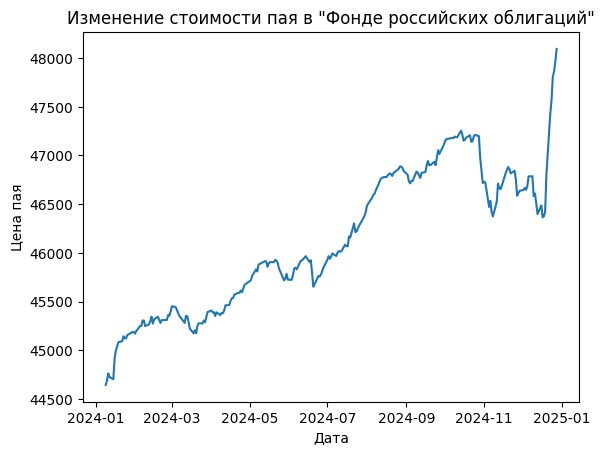

In [4]:
plt.title('Изменение стоимости пая в "Фонде российских облигаций"')
sns.lineplot(data, x=data.index, y="Фонд российских облигаций")
plt.xlabel("Дата")
plt.ylabel("Цена пая");

Рассмотрим корреляции доходностей открытых паев управляющей компании "Первая"

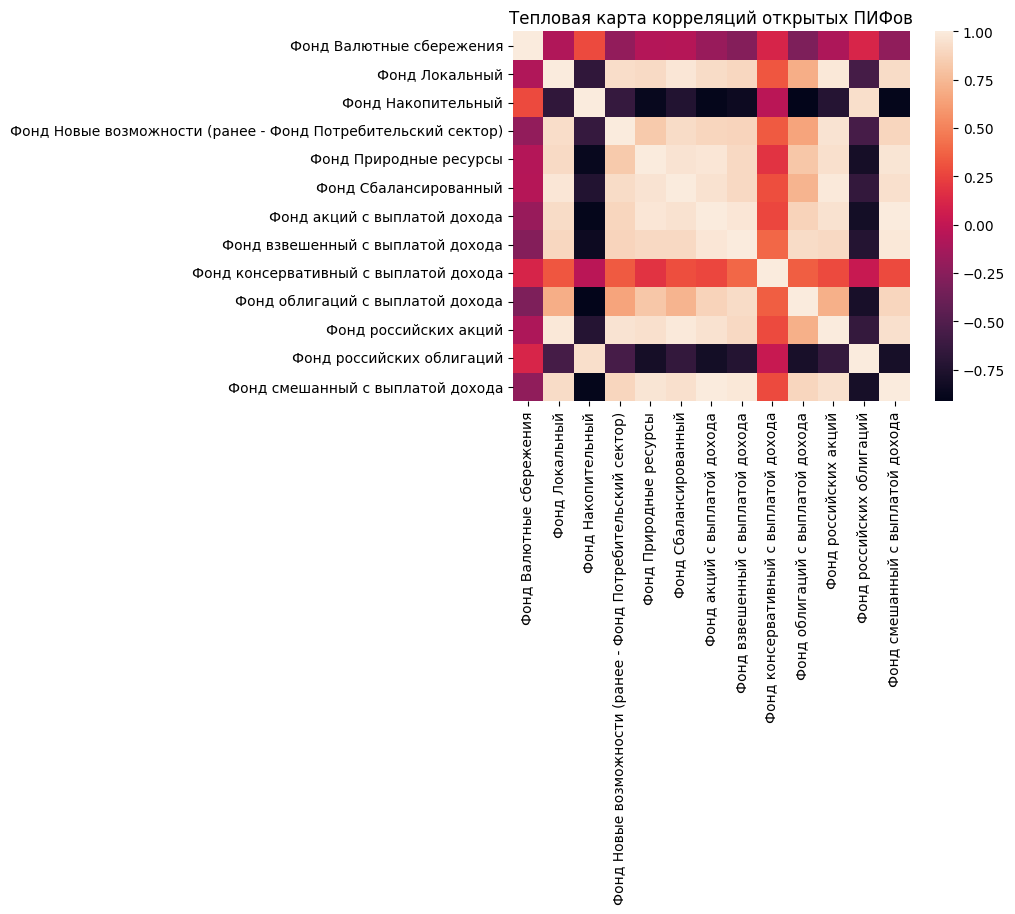

In [5]:
plt.figure()
plt.title("Тепловая карта корреляций открытых ПИФов")
sns.heatmap(data.corr(method="pearson", numeric_only=True));

Переход к дневным доходностям

In [6]:
data = data.diff() / data.shift(1)
data = data.iloc[1:]
data.head()

,Фонд Валютные сбережения,Фонд Локальный,Фонд Накопительный,Фонд Новые возможности (ранее - Фонд Потребительский сектор),Фонд Природные ресурсы,Фонд Сбалансированный,Фонд акций с выплатой дохода,Фонд взвешенный с выплатой дохода,Фонд консервативный с выплатой дохода,Фонд облигаций с выплатой дохода,Фонд российских акций,Фонд российских облигаций,Фонд смешанный с выплатой дохода
date,,,,,,,,,,,,,
2024-01-10,-0.000105,0.001172,-0.000056,0.006025,0.006400,0.004046,0.003686,-0.000297,0.000419,0.000177,0.005691,0.000948,0.002261
2024-01-11,-0.010319,0.003706,-0.000209,0.000344,0.005301,0.002923,0.013686,0.002512,0.000679,0.000535,0.005586,0.001709,0.008484
2024-01-12,0.000089,-0.000032,-0.000153,0.002197,0.006322,0.001978,0.000563,-0.000191,-0.000179,0.000184,0.004103,-0.000842,0.000144
2024-01-15,-0.010336,0.000032,0.000710,0.006973,0.001934,0.002895,0.001666,0.001123,0.000254,-0.000861,0.005385,-0.000481,0.001144
2024-01-16,-0.002611,0.000356,0.000285,-0.009783,-0.004023,-0.003108,-0.002221,-0.000325,0.000278,0.000047,-0.006189,0.004793,-0.001287


Наиболее привлекательные ПИФы по средней дневной доходности

In [7]:
data.mean().sort_values(ascending=False)

Фонд Накопительный                                              0.000518
Фонд Валютные сбережения                                        0.000505
Фонд российских облигаций                                       0.000303
Фонд Локальный                                                  0.000108
Фонд Сбалансированный                                           0.000049
Фонд российских акций                                           0.000034
Фонд консервативный с выплатой дохода                          -0.000039
Фонд Новые возможности (ранее - Фонд Потребительский сектор)   -0.000159
Фонд взвешенный с выплатой дохода                              -0.000219
Фонд облигаций с выплатой дохода                               -0.000319
Фонд Природные ресурсы                                         -0.000321
Фонд смешанный с выплатой дохода                               -0.000479
Фонд акций с выплатой дохода                                   -0.000622
dtype: float64

Рассмотрим изменения дохоодностей паев

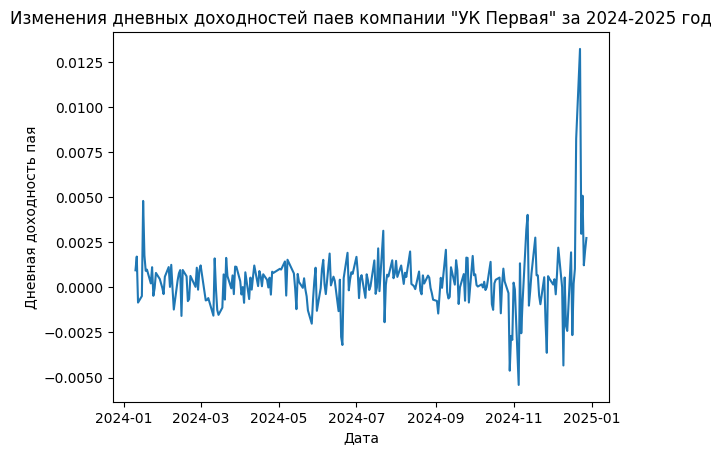

In [8]:
plt.title('Изменения дневных доходностей паев компании "УК Первая" за 2024-2025 год')
sns.lineplot(data, x=data.index, y="Фонд российских облигаций")
plt.xlabel("Дата")
plt.ylabel("Дневная доходность пая");

# Закрытые ПИФы

Выгружаем данные по закрытым ПИФам

In [9]:
# Широкая таблица стоимостей паёв закрытых ПИФов за 2024 год
mask = (
    (funds["fund_type"] == "closed")
    & (funds["date"] >= "2024-01-01")
    & (funds["date"] <= "2025-01-01")
)
data_closed = funds.loc[mask].pivot(index="date", columns="fund", values="price")
data_closed = data_closed[closed_funds]
data_closed.columns.name = None
data_closed.head()

,Фонд Современный 6,Фонд Современный Арендный бизнес 2
date,,
2024-01-31,357225.36,259302.23
2024-02-29,360365.24,262340.18
2024-03-29,355208.57,256960.96
2024-04-27,358404.37,259171.30
2024-05-31,368382.69,261332.69


Покажем, как менялась стоимость пая в закрытом "Фонде Современный Арендный бизнес 2"

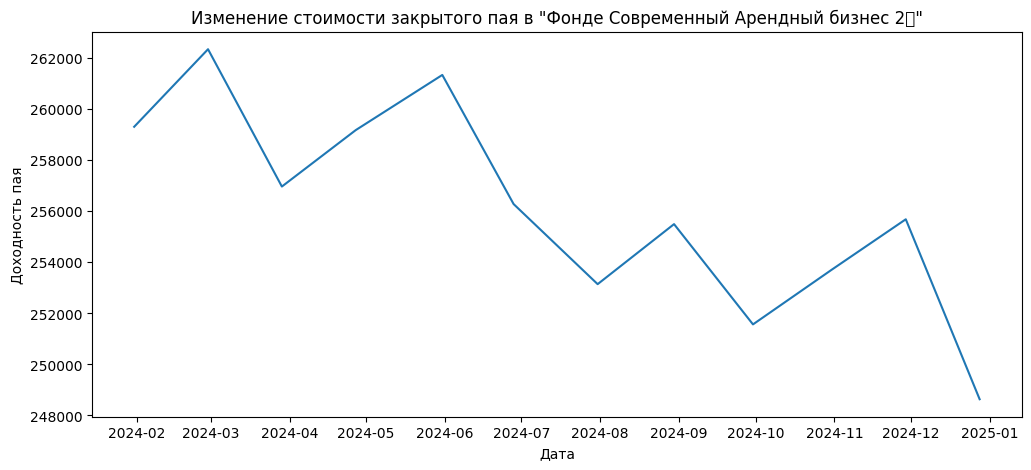

In [10]:
plt.figure(figsize=(12, 5))
plt.title('Изменение стоимости закрытого пая в "Фонде Современный Арендный бизнес 2	"')
sns.lineplot(data_closed, x=data_closed.index, y="Фонд Современный Арендный бизнес 2")
plt.xlabel("Дата")
plt.ylabel("Доходность пая");

Рассмотрим корреляции доходностей закрытых паев управляющей компании "Первая"

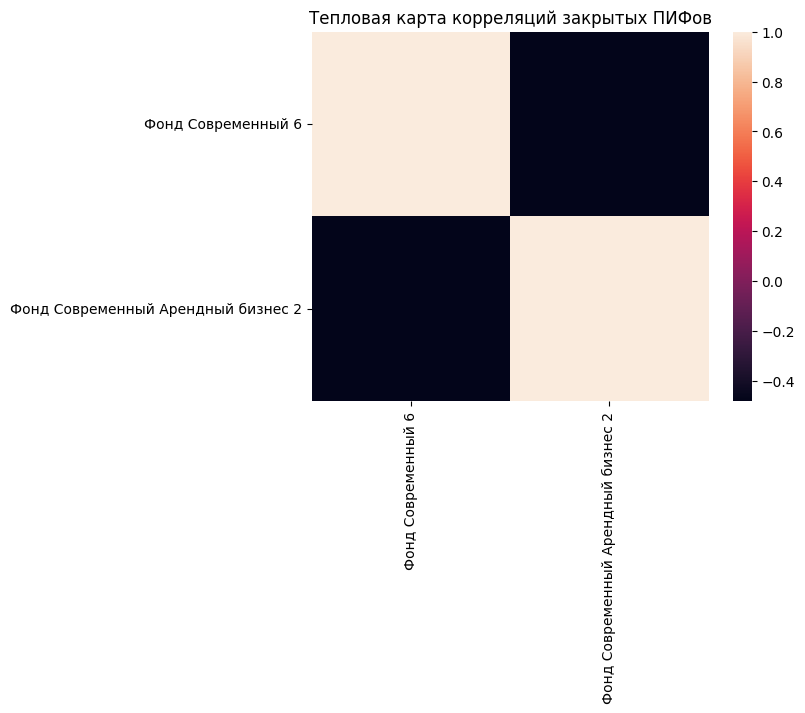

In [11]:
plt.figure()
plt.title("Тепловая карта корреляций закрытых ПИФов")
sns.heatmap(data_closed.corr(method="pearson"));

Переход к доходностям

In [12]:
data_closed = data_closed.diff() / data_closed.shift(1)
data_closed = data_closed.iloc[1:]
data_closed

,Фонд Современный 6,Фонд Современный Арендный бизнес 2
date,,
2024-02-29,0.008790,0.011716
2024-03-29,-0.014310,-0.020505
2024-04-27,0.008997,0.008602
2024-05-31,0.027841,0.008340
2024-06-28,-0.013553,-0.019353
2024-07-31,0.008707,-0.012243
2024-08-30,0.008626,0.009289
2024-09-30,-0.012303,-0.015372
2024-10-31,0.030115,0.008536


Рассмотрим изменение доходностей закрытых паев компании "УК Первая" за 2024-2025 год

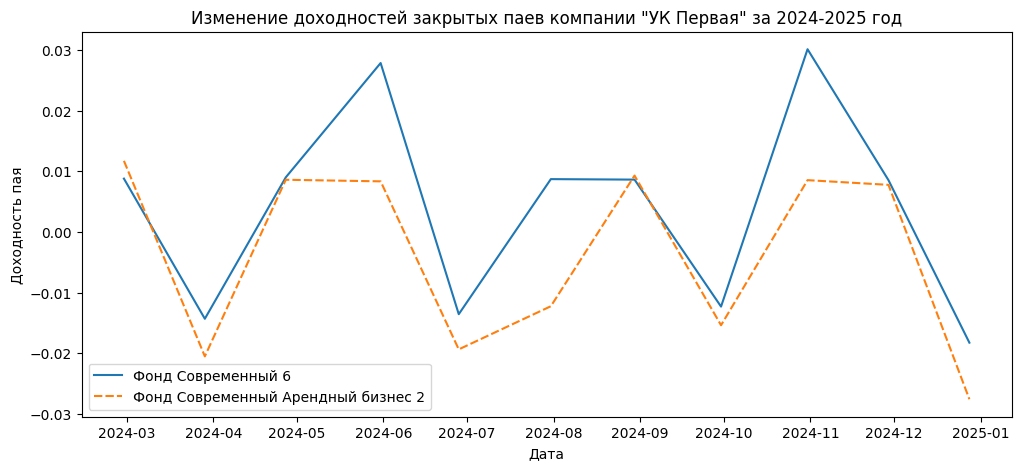

In [13]:
plt.figure(figsize=(12, 5))
sns.lineplot(data_closed)
plt.title('Изменение доходностей закрытых паев компании "УК Первая" за 2024-2025 год')
plt.xlabel("Дата")
plt.ylabel("Доходность пая");

Наиболее привлекательные ЗПИФы по средней дневной доходности

In [14]:
data_closed.mean().sort_values(ascending=False)

Фонд Современный 6                    0.003928
Фонд Современный Арендный бизнес 2   -0.003708
dtype: float64

# Оценка привлекательности открытых ПИФов

Дневная доходность

<Figure size 640x480 with 0 Axes>

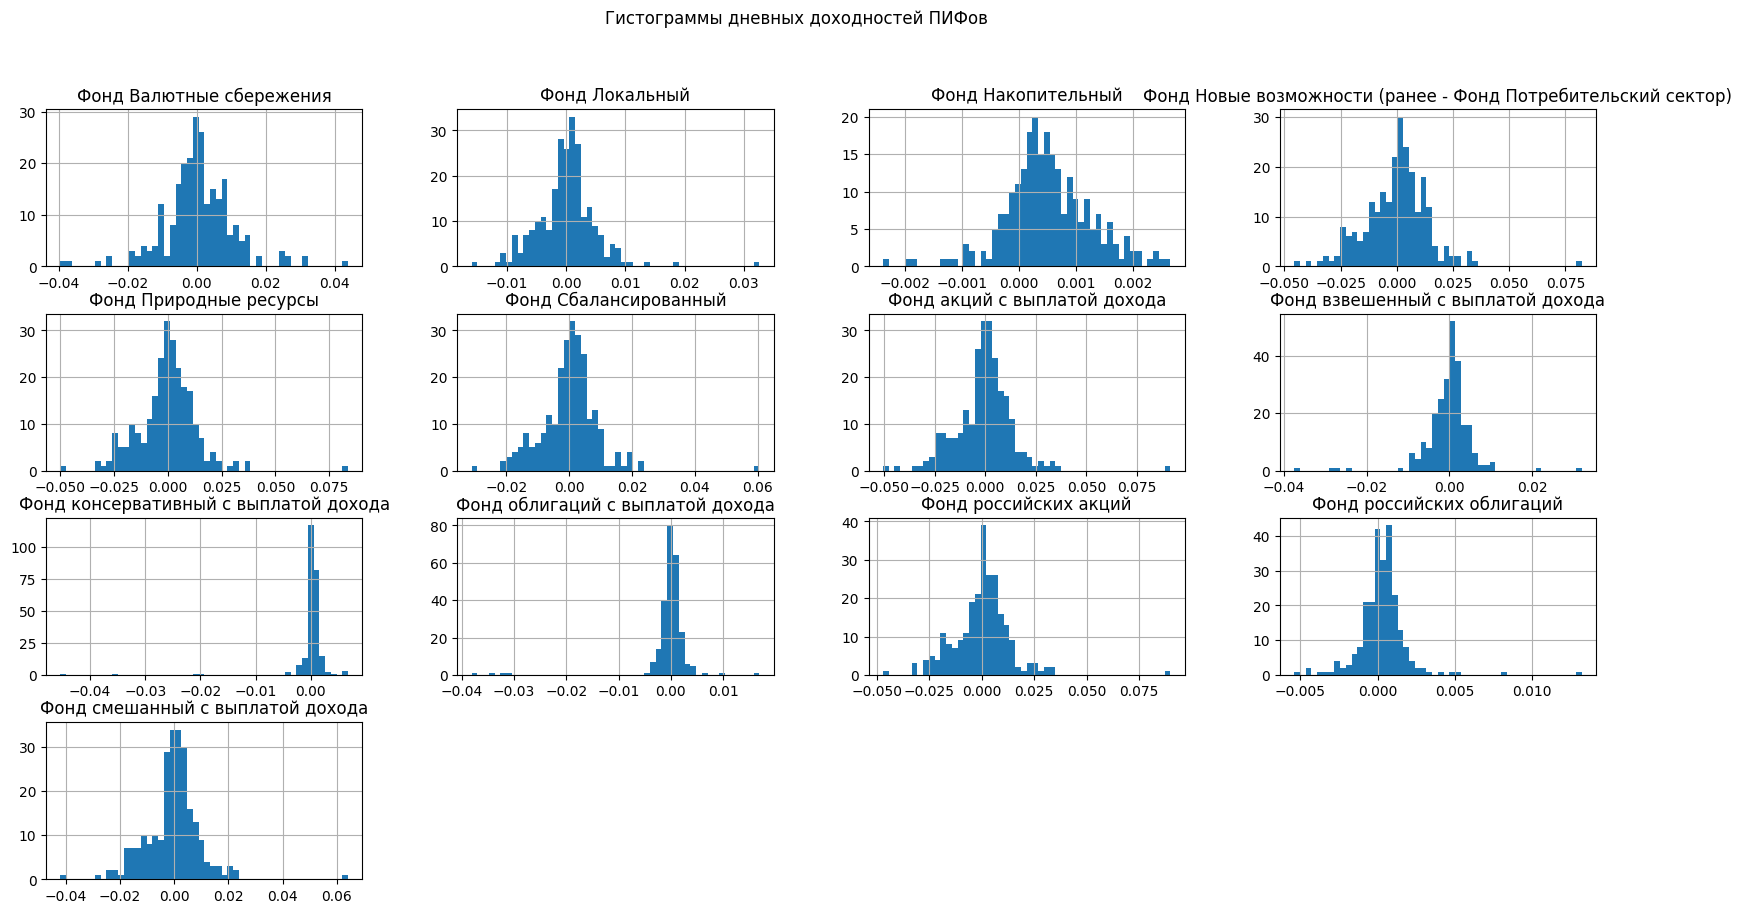

In [15]:
daily_returns = data.copy()
plt.figure()
daily_returns.hist(bins=50, figsize=(20, 10))
plt.suptitle("Гистограммы дневных доходностей ПИФов");

Накопленная (кумулятивная доходность)

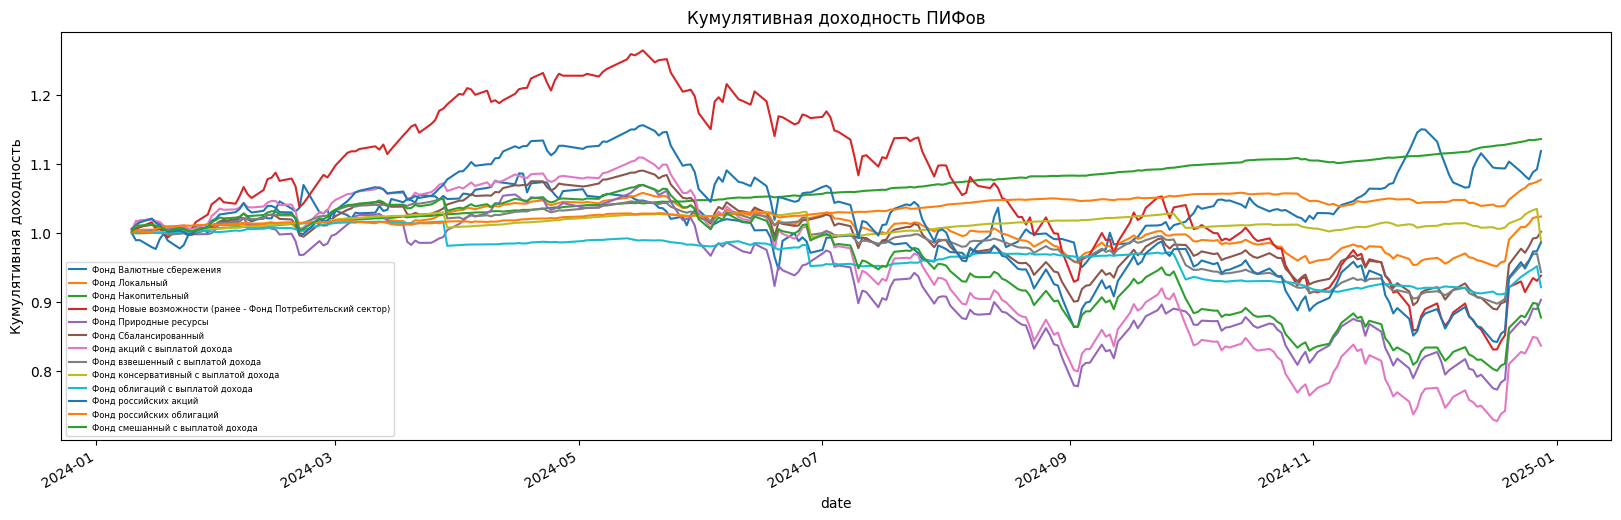

In [16]:
cum_daily_return = (1 + daily_returns).cumprod()
cum_daily_return.plot(figsize=(20, 6))
plt.title("Кумулятивная доходность ПИФов")
plt.ylabel("Кумулятивная доходность")
plt.legend(loc="lower left", fontsize="6");

Рейтинг ПИФов по убыванию годовой накопленной доходности

In [17]:
yearly_returns = cum_daily_return.iloc[-1, 1:]
print(
    f"Годовая доходность (по убыванию, в %)\n\n{100 * (yearly_returns.sort_values(ascending=False) - 1)}"
)

Годовая доходность (по убыванию, в %)

Фонд Накопительный                                              13.629250
Фонд российских облигаций                                        7.727845
Фонд Локальный                                                   2.398815
Фонд Сбалансированный                                            0.182141
Фонд консервативный с выплатой дохода                           -1.181343
Фонд российских акций                                           -1.371651
Фонд взвешенный с выплатой дохода                               -5.660520
Фонд Новые возможности (ранее - Фонд Потребительский сектор)    -6.175515
Фонд облигаций с выплатой дохода                                -7.847605
Фонд Природные ресурсы                                          -9.684242
Фонд смешанный с выплатой дохода                               -12.236334
Фонд акций с выплатой дохода                                   -16.322309
Name: 2024-12-28 00:00:00, dtype: float64


Рассчитаем волатильность

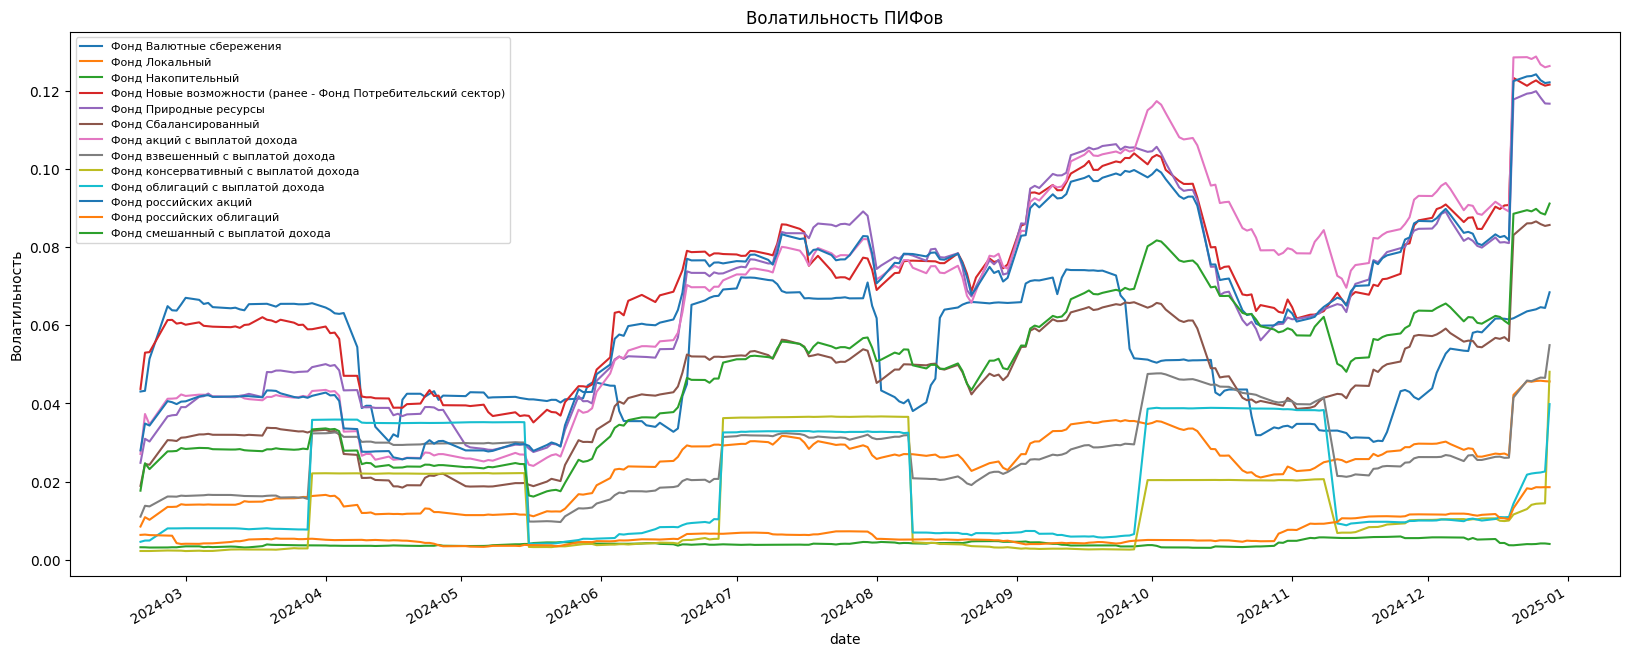

In [18]:
min_periods = 30
volatility = daily_returns.rolling(min_periods).std() * np.sqrt(min_periods)

volatility.plot(figsize=(20, 8))
plt.title("Волатильность ПИФов")
plt.ylabel("Волатильность")
plt.legend(loc="upper left", fontsize="8");

Рейтинг ПИФов по убыванию среднемесячной волатильности

In [19]:
avg_volatility = volatility.mean().sort_values(ascending=False)
print(f"Среднемесячная волатильность (по убыванию, в %):\n\n{avg_volatility * 100}")

Среднемесячная волатильность (по убыванию, в %):

Фонд Новые возможности (ранее - Фонд Потребительский сектор)    7.154123
Фонд акций с выплатой дохода                                    6.897248
Фонд Природные ресурсы                                          6.759528
Фонд российских акций                                           6.626440
Фонд Валютные сбережения                                        5.322492
Фонд смешанный с выплатой дохода                                4.816437
Фонд Сбалансированный                                           4.470144
Фонд взвешенный с выплатой дохода                               2.744528
Фонд Локальный                                                  2.413926
Фонд облигаций с выплатой дохода                                1.965275
Фонд консервативный с выплатой дохода                           1.408407
Фонд российских облигаций                                       0.640259
Фонд Накопительный                                              0.407049
d

Будем исходить из предпосылки, что основной потребитель таких рэнкингов - долгосрочный инвестор, так как ПИФы не обладают значительными спекулятивными возможностями, и нацелены все же на более консервативную аудиторию. Да, существуют ПИФы с агрессивной стратегией инвестирования, но их высокий риск (волатильность, в нашем случае) должен компенсироваться высокой доходностью.

Тогда, так как мы смотрим на долгосрочное инвестирование, то оценку и переоценку следует проводить приблизительно раз в год, кроме случаев, когда ПИФ значительно изменяет свою внутреннюю структуру.

Два главных показателя, на которые следует в данном случае опираться - доходность, которая интересует каждого из инвесторов, и волатильность, которая в наибольшей степени отражает риски, которые несёт конкретный ПИФ. 

Так как мы не обладаем рыночной информацией о ликвидности самих ПИФов, то будем опираться на ранжирование, которое предлагает сама УК Первая. Да, это в некоторой мере предвязатая информация, но это лучшее, что мы имеем. Также впоследствии придется создаться отдельную шкалу для перевода их показателей в значения, которые мы сможем использовать уже при создании рейтинга.

<i>Очевидно, что и волатильность, и доходностью следуют из содержимого ПИФа, но важно отметить, что именно волатильность стоимости пая одновременно отображает, насколько качественно диверсифицировано содержимое ПИФа самой управляющей компанией</i>

Важное замечание: при первичной оценке ПИФа (в момент его появления), следует опираться на историческую доходность, ликвидность и волатильность его содержимого и брать средневзвешенные значения, в тех пропорциях или долях, которые заявляются самой управляющей компанией.

И, конечно, нам важно, чтобы сама управляющая компания была достаточно обеспечена и стабильна, иначе нам вообще не смогут потом вернуть наши же вложения. Поэтому мы будем опираться на ряд финансовых показателей (аналогично, годовых):
- Кредитные рэнкинги (собственно, они являются главным для нас ориентиром, который показывает, как у компапнии обстоят дела в целом)
- Рентабельность (ну, и как у них вообще с заработками)

<a href='https://www.first-am.ru/download/17256/audit_report.pdf'>Финансовые показатели УК Первая</a>  
<a href='https://raexpert.ru/releases/2024/dec27h'>Рейтинговое заключение РА Эксперт</a>

Теперь необходимо ввести собственные веса для оценки ПИФа. Попробуем сделать ранжирование SMART-методом, где обозначим за наименьший - рентабельность. Это не слишком формализованные веса, а скорее интуитивно предполагаемые для описания предпочтений рядового инвестора, скорее физического лица. На это тоже стоит обратить внимание, так как предпочтения и ожидания институциональных инвесторов нам явно сложнее будет предсказать.

Рентабельность - 10;  
Ликвидность - 20;  
Кредитные рэнкинги (они включают в себя и ликвидность, и рентабельность, и значительно больше других показателей, особенно качественных, и в силу их экспертизы, мы можем полагаться на них) - 50;  
Волатильность - 50;  
Доходность - 70;  

Теперь получим и сами коэффициенты:   
Рентабельность - 5%    
Ликвидность - 10%  
Кредитные (ну, на самом деле некридитные) рэнкинги  - 25%  
Волатильность - 25%  
Доходность - 35%  

Шкала для перевода из рейтингов:  
A++ - 10  
A+ - 8   
A - 6  
Другие (отозванные, чаще всего) - ноль. У РА Эксперт других, к примеру, даже нет.

Шкала для превода значений ликвидности (трехбалльная) от УК Первая:  
3/3 - 10  
2/3 - 7  
1/3 - 4  

In [20]:
company_data = [54.3, 2, 10]  # данные по УК Первая: рентабельность, ликвидность, рэнкинг
# также отметим про ликвидность: у всех ПИФов, которые мы в данной ситуации рассматриваем, она одинаковая (2/3).
weights = [0.05, 0.1, 0.25, 0.25, 0.35]

In [21]:
# Ранжируем по доходности. Больше - лучше.
def returns_quality(yearly_returns, name):
    x = (yearly_returns[name].item() - 1) * 100
    if x >= 20:
        return 10
    elif x >= 15:
        return 8
    elif x >= 10:
        return 6
    elif x >= 5:
        return 4
    else:
        return 0

In [22]:
# Ранжируем по волатильности. Больше - хуже.
def volatily_quality(avg_volatility, name):
    y = avg_volatility[name].item() * 100
    if y >= 30:
        return 0
    elif y >= 20:
        return 2
    elif y >= 15:
        return 4
    elif y >= 10:
        return 6
    elif y >= 5:
        return 8
    elif y >= 3:
        return 9
    else:
        return 10

In [23]:
# Ранжируем финансовые показатели компании. Смотрите в код.
# Опирались на общее ощущение от того, что РА Эксперт считает качественным показателем или нет.
# Чем выше каждый показатель, тем лучше для фирмы.


def company_data_conversion(company_data):
    """сначала переводим значения рентабельности"""
    company_data_updated = company_data.copy()
    if company_data_updated[0] >= 50:
        company_data_updated[0] = 10
    elif company_data_updated[0] >= 40:
        company_data_updated[0] = 8
    elif company_data_updated[0] >= 30:
        company_data_updated[0] = 6
    elif company_data_updated[0] >= 20:
        company_data_updated[0] = 4
    elif company_data_updated[0] >= 10:
        company_data_updated[0] = 2
    else:
        company_data_updated[0] = 0

    """ теперь ликвидность (самих ПИФов, а не компании)"""
    if company_data_updated[1] == 3:
        company_data_updated[1] = 10
    elif company_data_updated[1] == 2:
        company_data_updated[1] = 7
    elif company_data_updated[1] == 2:
        company_data_updated[1] = 4
    else:
        company_data_updated[1] = 0
    return company_data_updated

In [24]:
# Сводим все к единому числу, переможная все значения по весам.
def ranking(company_data, weights, avg_volatility, yearly_returns, name):
    full_comany_data = company_data_conversion(company_data) + [
        returns_quality(yearly_returns, name),
        volatily_quality(avg_volatility, name),
    ]
    rating = 0
    for i in range(len(full_comany_data)):
        rating += full_comany_data[i] * weights[i]
    return round(rating, 2)

In [25]:
# Получаем качественные (словесные) оценки, исходя из полученного значения
def verbal_result(rating_score):
    if rating_score > 8:
        return "Очень высокая привлекательность"
    elif rating_score > 6:
        return "Средния привлекательность"
    elif rating_score > 4:
        return "Низкая привлекательность"
    else:
        return "Очень низкая привлекательность"

In [26]:
names = ["Фонд Накопительный", "Фонд российских акций", "Фонд Сбалансированный"]
# Пробежимся по трем фондам, которые разбирались в начале
for name in names:
    score = ranking(company_data, weights, avg_volatility, yearly_returns, name)
    print(f"{name}: {verbal_result(score)}, Рейтинг - {score}")

Фонд Накопительный: Очень высокая привлекательность, Рейтинг - 8.7
Фонд российских акций: Средния привлекательность, Рейтинг - 6.5
Фонд Сбалансированный: Средния привлекательность, Рейтинг - 6.85


# Прогнозирование изменения стоимости ПИФов

<img src="https://i.ibb.co/JFjWcmbM/8b40a77d85bd4bfd88d07ba7c3975497.png" alt="8b40a77d85bd4bfd88d07ba7c3975497" border="0">

Для прогнозирования временных рядов используются:
* ARIMA
* ARCH
* регрессионные модели
* рекуррентные нейронные сети
* бустинговые модели

Мы будем использовать готовое решение для прогнозирования временных рядов $-$ библиотеку `prophet`. В библиотеке реализована `additive regression model` вида $y(t)=g(t)+s(t)+h(t)+\varepsilon_t$, где \begin{cases} s(t) \text{$-$ сезонная компонента} \\ g(t) \text{$-$ тренд в виде сигмоиды вида $\cfrac{C}{1+\exp(-k(t-b))}$} \\ h(t) \text{аномальные составляющие} \\ \varepsilon_t \text{$-$ случайная ошибка модели} \\ \end{cases}

In [27]:
prognret = []
means = []
stds = []

### Фонд "Накопительный"

Загружаем и обрабатываем данные

In [28]:
# Полная история дневных доходностей фонда для прогноза
asset = funds.loc[funds["fund"] == "Фонд Накопительный", ["date", "price"]].copy()
asset.columns = ["ds", "y"]
asset["y"] = asset["y"].diff() / asset["y"].shift(1)
asset = asset.iloc[1:]
asset

,ds,y
3393,2017-12-18,-0.000060
3394,2017-12-19,-0.000370
3395,2017-12-20,-0.000170
3396,2017-12-21,0.000060
3397,2017-12-22,0.000090
...,...,...
5155,2025-03-14,0.000582
5156,2025-03-17,0.002091
5157,2025-03-18,-0.000229
5158,2025-03-19,0.000932


Строим модель

In [29]:
df_prophet = asset[["ds", "y"]]

model = Prophet()
model.fit(df_prophet)

future = model.make_future_dataframe(periods=360 * 3)
forecast = model.predict(future)

19:07:59 - cmdstanpy - INFO - Chain [1] start processing


19:07:59 - cmdstanpy - INFO - Chain [1] done processing


In [30]:
data = forecast["yhat"][forecast["ds"] >= "2025-01-01"]
daily_returns = data.tolist()
daily_growth_factors = [1 + ret / 100 for ret in daily_returns]
cumulative_growth_factor = np.prod(daily_growth_factors)
cumulative_return = cumulative_growth_factor - 1
prognret.append(cumulative_return)
means.append(np.mean(data))
stds.append(np.std(data, ddof=1))

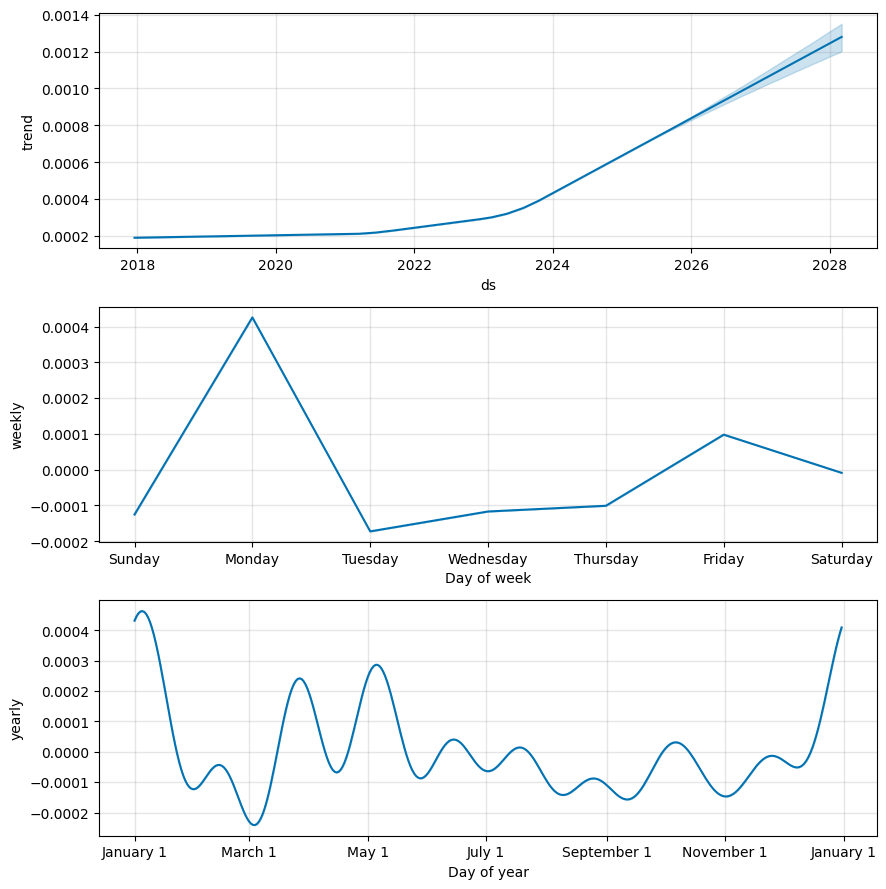

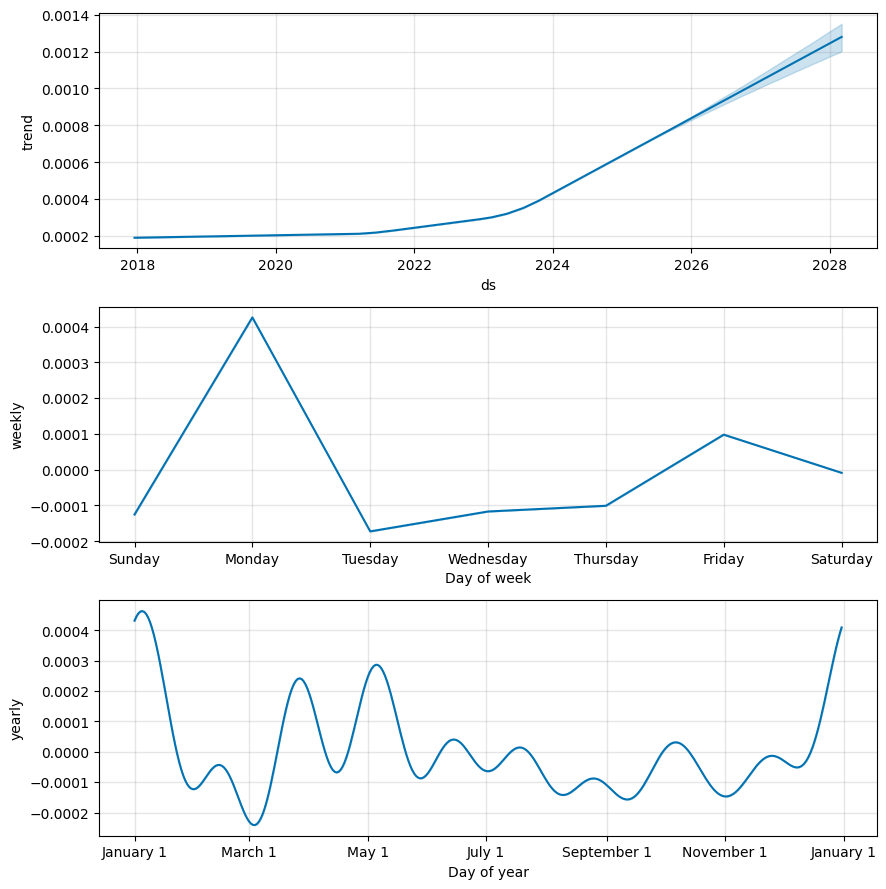

In [31]:
model.plot_components(forecast)

Смотрим на прогноз

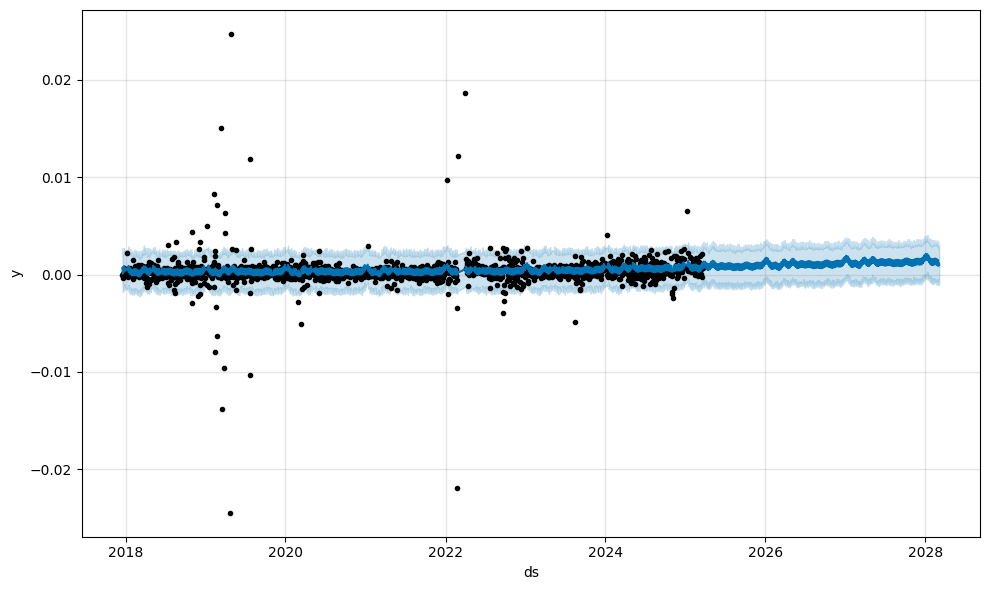

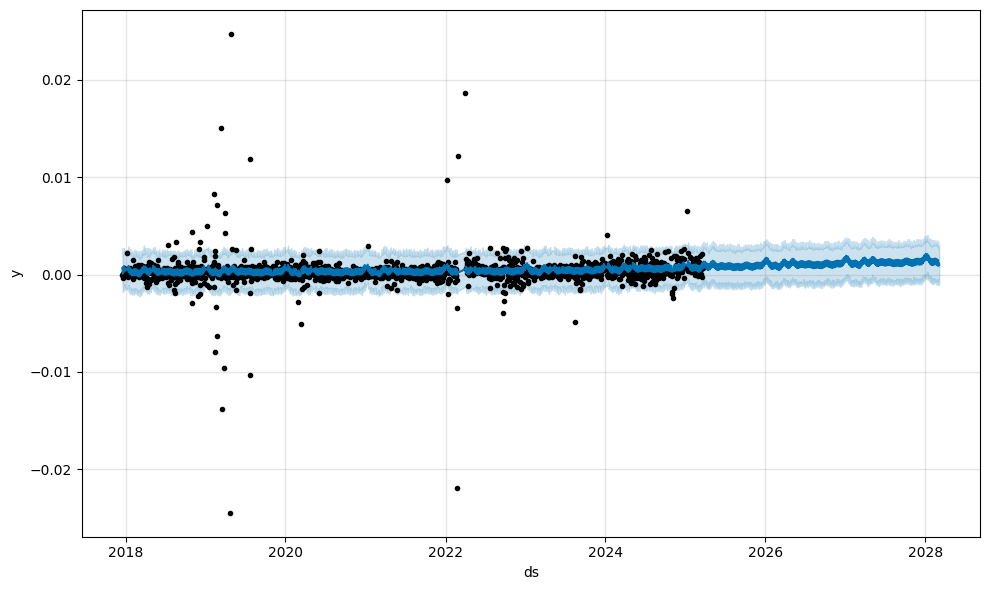

In [32]:
model.plot(forecast)

Рассчитаем Value-at-Risk и Expected Shortfall

In [33]:
nakopvar = asset["y"].quantile(0.05)
nakopes = asset[asset["y"] < asset["y"].quantile(0.05)]["y"].mean()
print(
    f"""VaR: {asset["y"].quantile(0.05)}\nES: {asset[asset["y"] < asset["y"].quantile(0.05)]["y"].mean()}"""
)

VaR: -0.000680749713794494
ES: -0.0023691426532286316


### Фонд российских акций

Загружаем и обрабатываем данные

In [34]:
# Полная история дневных доходностей фонда для прогноза
asset = funds.loc[funds["fund"] == "Фонд российских акций", ["date", "price"]].copy()
asset.columns = ["ds", "y"]
asset["y"] = asset["y"].diff() / asset["y"].shift(1)
asset = asset.iloc[1:]
asset

,ds,y
21914,1997-06-06,0.000000
21915,1997-06-09,0.000000
21916,1997-06-10,0.000000
21917,1997-06-11,0.000000
21918,1997-06-12,0.000000
...,...,...
28797,2025-03-14,0.022429
28798,2025-03-17,0.011946
28799,2025-03-18,0.006113
28800,2025-03-19,-0.004773


Строим модель

In [35]:
df_prophet = asset[["ds", "y"]]

model = Prophet()
model.fit(df_prophet)

future = model.make_future_dataframe(periods=360 * 3)
forecast = model.predict(future)

19:08:00 - cmdstanpy - INFO - Chain [1] start processing


19:08:00 - cmdstanpy - INFO - Chain [1] done processing


In [36]:
data = forecast["yhat"][forecast["ds"] >= "2025-01-01"]
daily_returns = data.tolist()
daily_growth_factors = [1 + ret / 100 for ret in daily_returns]
cumulative_growth_factor = np.prod(daily_growth_factors)
cumulative_return = cumulative_growth_factor - 1
prognret.append(cumulative_return)
means.append(np.mean(data))
stds.append(np.std(data, ddof=1))

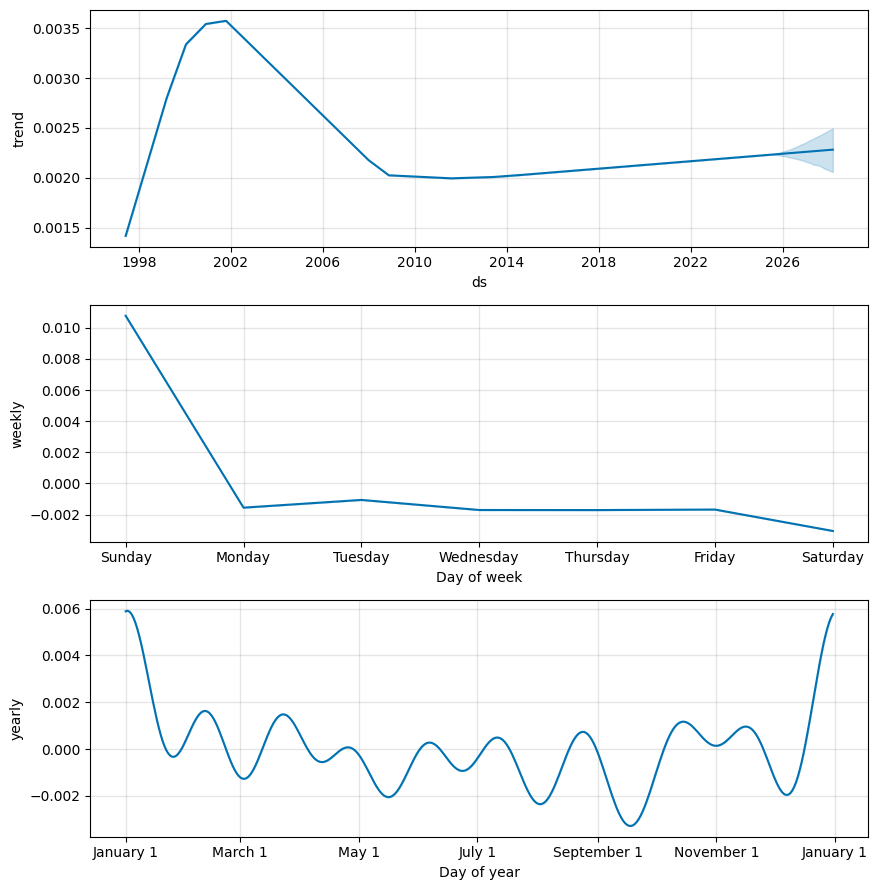

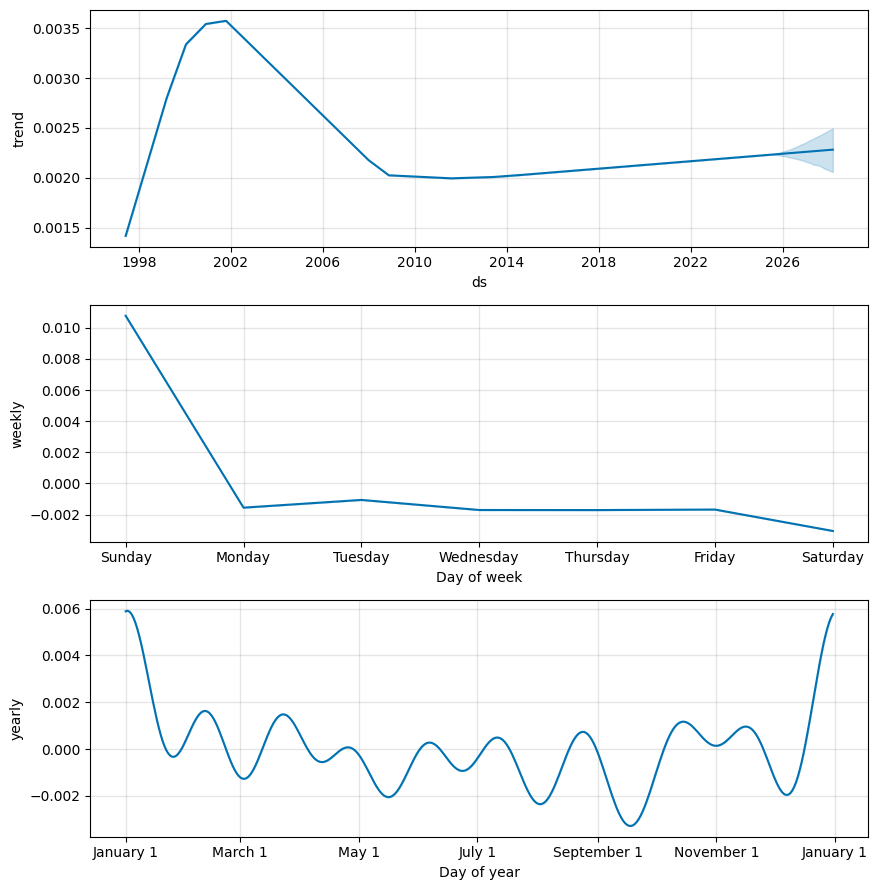

In [37]:
model.plot_components(forecast)

Смотрим на прогноз

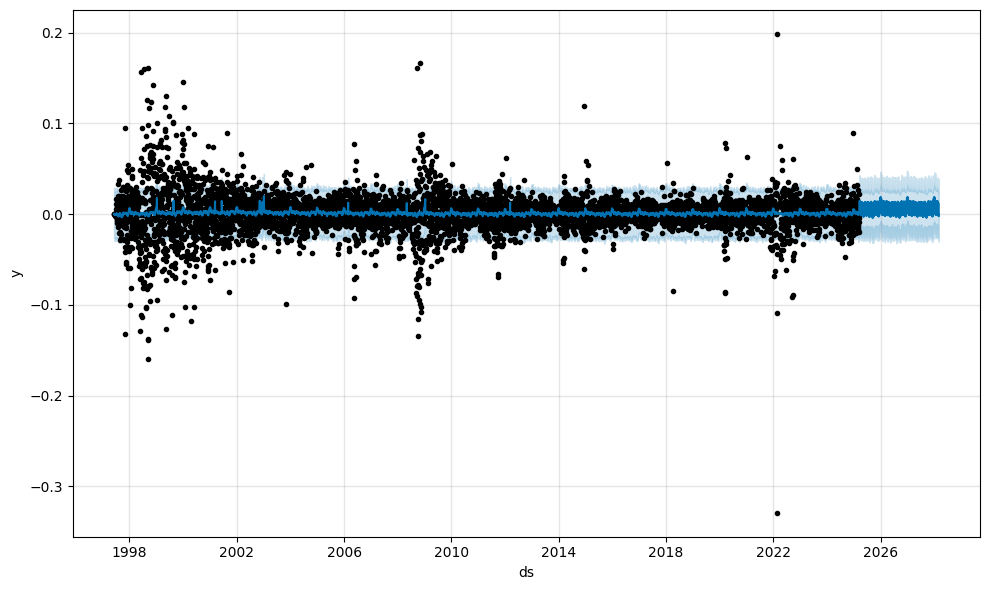

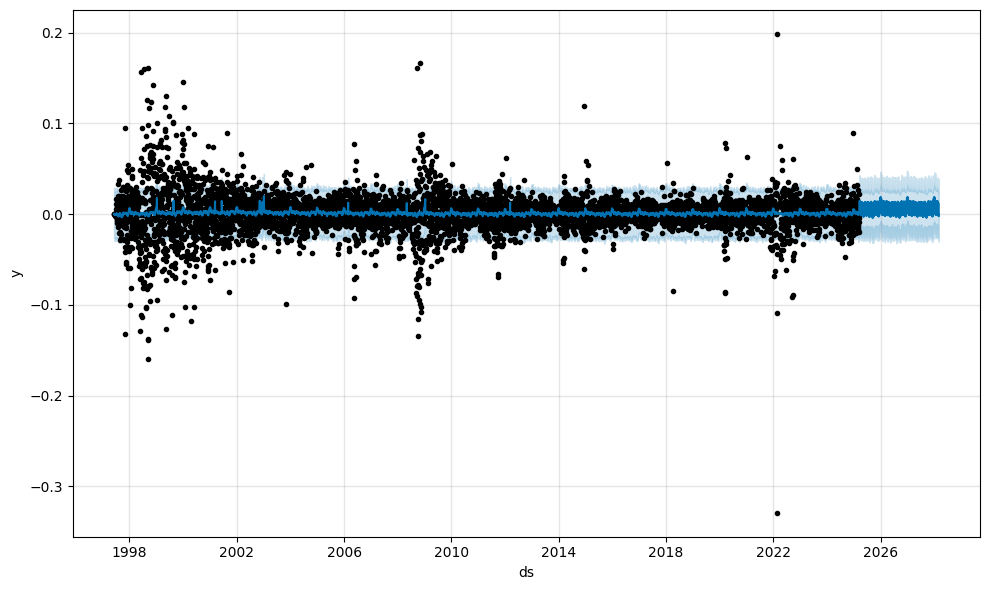

In [38]:
model.plot(forecast)

Рассчитаем Value-at-Risk и Expected Shortfall

In [39]:
rosacvar = asset["y"].quantile(0.05)
rosaces = asset[asset["y"] < asset["y"].quantile(0.05)]["y"].mean()
print(
    f"""VaR: {asset["y"].quantile(0.05)}\nES: {asset[asset["y"] < asset["y"].quantile(0.05)]["y"].mean()}"""
)

VaR: -0.029416643522807585
ES: -0.05175964927145502


### Фонд "Сбалансированный"

Загружаем и обрабатываем данные

In [40]:
# Полная история дневных доходностей фонда для прогноза
asset = funds.loc[funds["fund"] == "Фонд Сбалансированный", ["date", "price"]].copy()
asset.columns = ["ds", "y"]
asset["y"] = asset["y"].diff() / asset["y"].shift(1)
asset = asset.iloc[1:]
asset

,ds,y
13680,2001-04-03,-0.000370
13681,2001-04-04,-0.000123
13682,2001-04-05,-0.000124
13683,2001-04-06,-0.000123
13684,2001-04-09,-0.000369
...,...,...
19598,2025-03-14,0.016537
19599,2025-03-17,0.009936
19600,2025-03-18,0.004492
19601,2025-03-19,-0.004271


Строим модель

In [41]:
df_prophet = asset[["ds", "y"]]

model = Prophet()
model.fit(df_prophet)

future = model.make_future_dataframe(periods=360 * 3)
forecast = model.predict(future)

19:08:02 - cmdstanpy - INFO - Chain [1] start processing


19:08:02 - cmdstanpy - INFO - Chain [1] done processing


In [42]:
data = forecast["yhat"][forecast["ds"] >= "2025-01-01"]
daily_returns = data.tolist()
daily_growth_factors = [1 + ret / 100 for ret in daily_returns]
cumulative_growth_factor = np.prod(daily_growth_factors)
cumulative_return = cumulative_growth_factor - 1
prognret.append(cumulative_return)
means.append(np.mean(data))
stds.append(np.std(data, ddof=1))

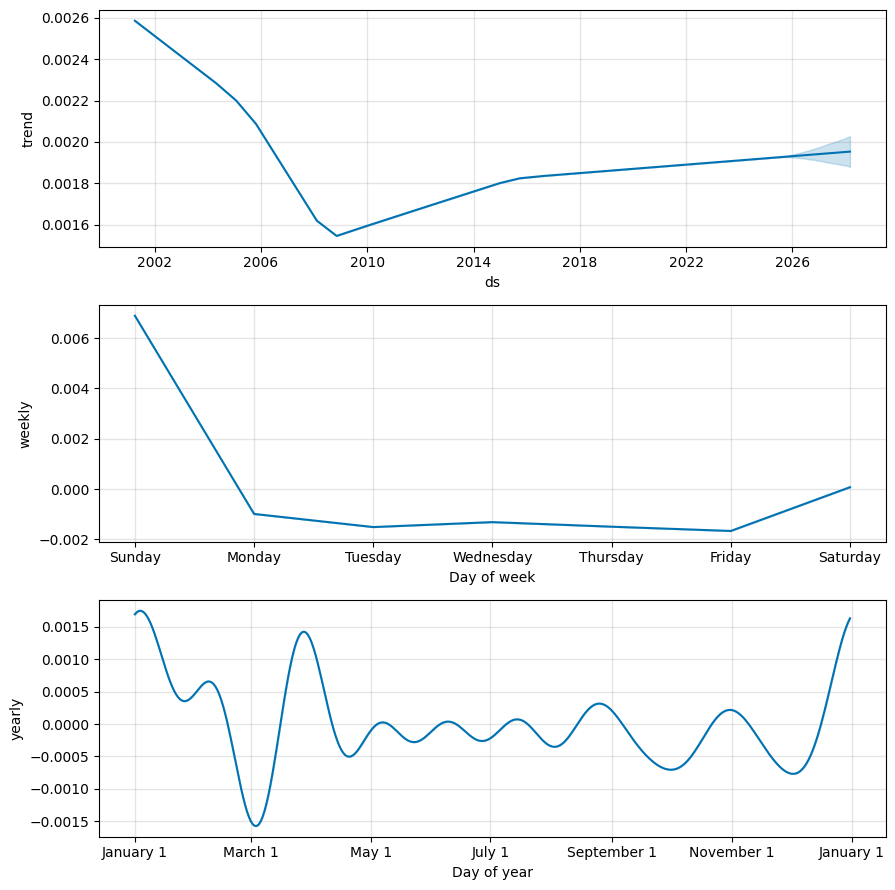

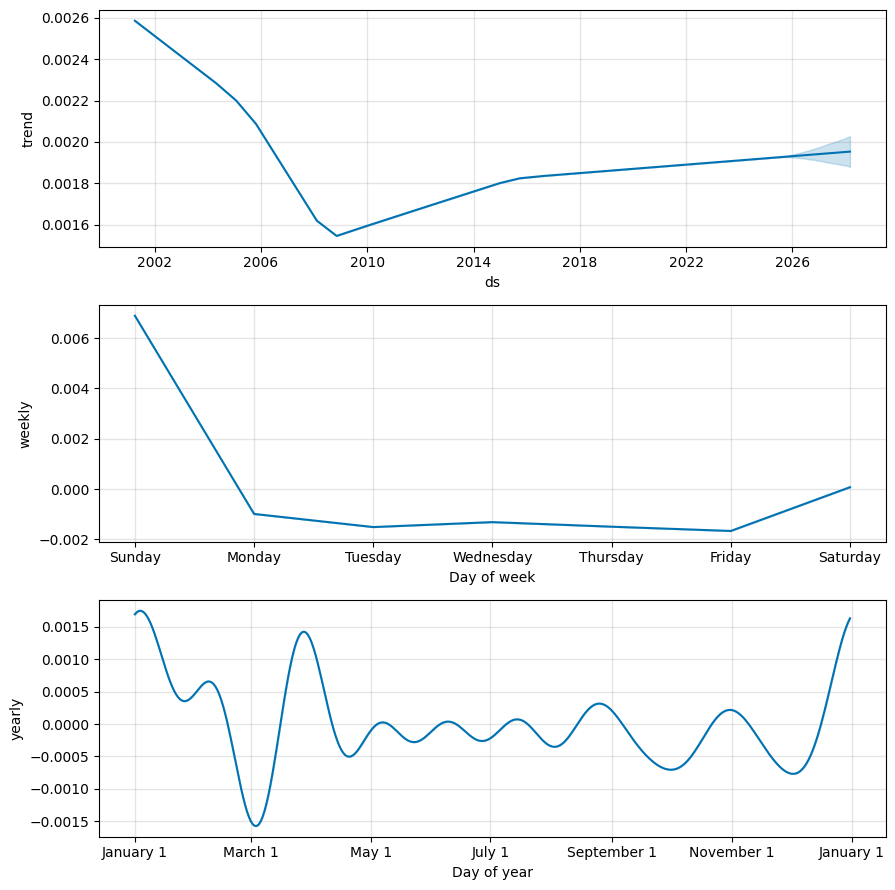

In [43]:
model.plot_components(forecast)

Смотрим на прогноз

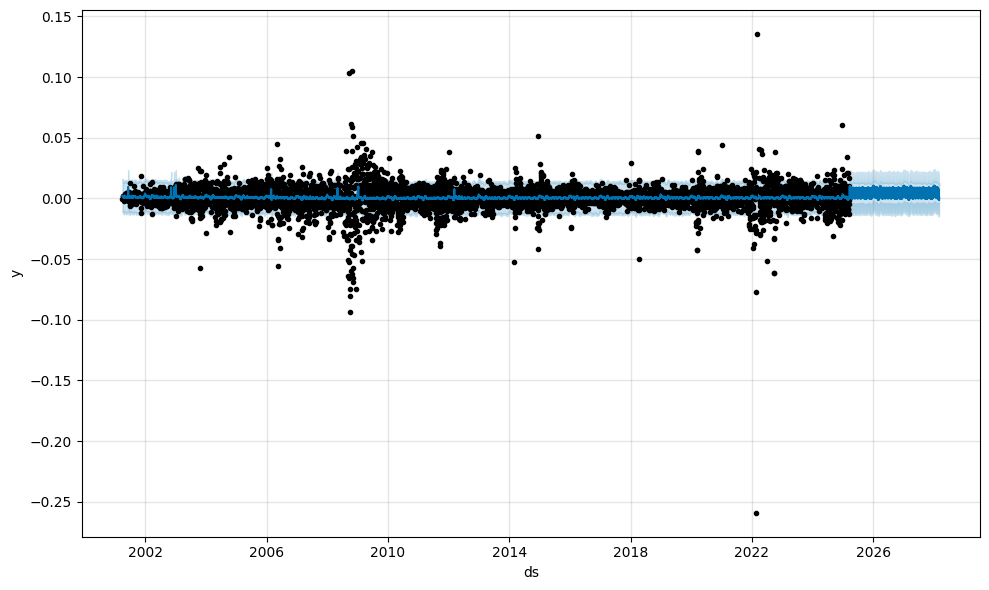

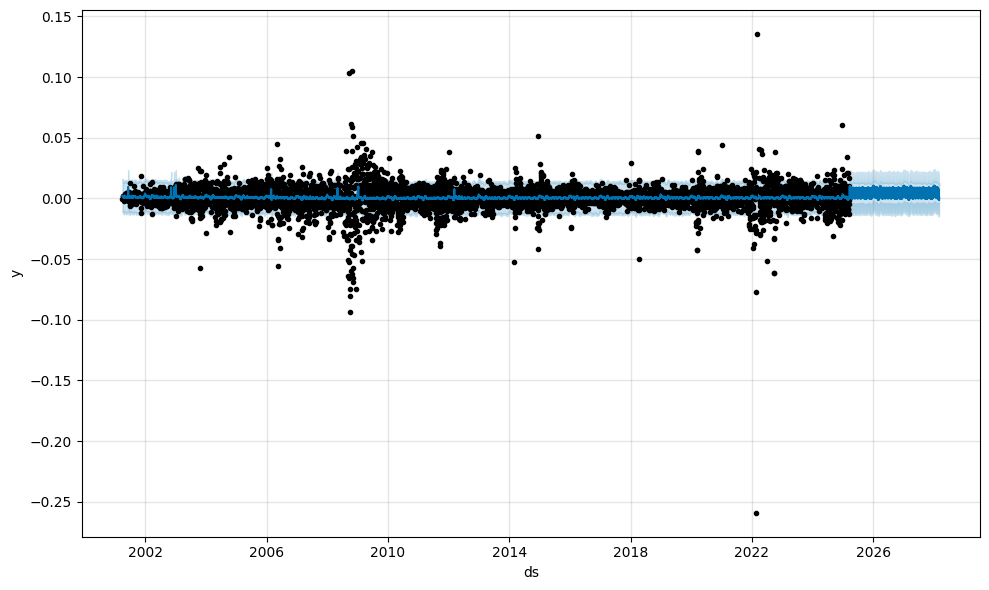

In [44]:
model.plot(forecast)

Рассчитаем Value-at-Risk и Expected Shortfall

In [45]:
balansvar = asset["y"].quantile(0.05)
balanses = asset[asset["y"] < asset["y"].quantile(0.05)]["y"].mean()
print(
    f"""VaR: {asset["y"].quantile(0.05)}\nES: {asset[asset["y"] < asset["y"].quantile(0.05)]["y"].mean()}"""
)

VaR: -0.013092029466771639
ES: -0.024758602568798024


# Привлекательность ПИФа на основе прогноза

In [46]:
dd = dict()
varis = [nakopvar, rosacvar, balansvar]
esis = [nakopes, rosaces, balanses]
colors = ["r", "b", "g"]
dd["Фонд"] = ["Накопительный", "Фонд российских акций", "Сбалансированный"]
dd["VaR"] = varis
dd["VaR"] = np.abs(dd["VaR"])
dd["ES"] = esis
dd["ES"] = np.abs(dd["ES"])
dd["Накопленная прогнозная доходность"] = prognret
dd["Средняя дневная доходность"] = means
dd["Std"] = stds
base = 0.1527  # https://cbr.ru/hd_base/zcyc_params/zcyc/
dn_bezrisk = (1 + base) ** (1 / 365) - 1
tabl = pd.DataFrame(dd)
tabl["Коэф-т Шарпа"] = (tabl["Средняя дневная доходность"] - dn_bezrisk) / tabl["Std"]
tabl

,Фонд,VaR,ES,Накопленная прогнозная доходность,Средняя дневная доходность,Std,Коэф-т Шарпа
0,Накопительный,0.000681,0.002369,0.010983,0.000966,0.000301,1.912647
1,Фонд российских акций,0.029417,0.051760,0.025239,0.002204,0.004651,0.390168
2,Сбалансированный,0.013092,0.024759,0.021516,0.001882,0.002887,0.517169


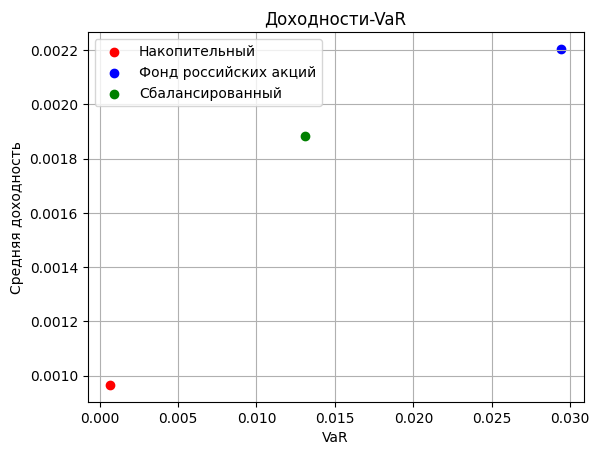

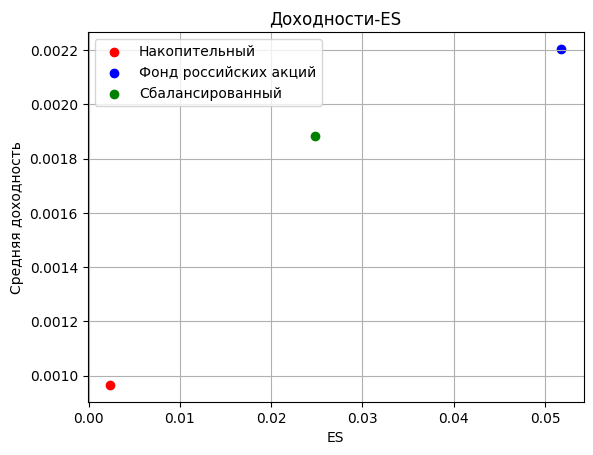

In [47]:
for i in range(3):
    plt.scatter(dd["VaR"][i], means[i], label=dd["Фонд"][i], color=colors[i])
plt.xlabel("VaR")
plt.ylabel("Средняя доходность")
plt.title("Доходности-VaR")
plt.legend()
plt.grid(True)
plt.show()
for i in range(3):
    plt.scatter(dd["ES"][i], means[i], label=dd["Фонд"][i], color=colors[i])
plt.xlabel("ES")
plt.ylabel("Средняя доходность")
plt.title("Доходности-ES")
plt.legend()
plt.grid(True)
plt.show();

# Выводы

Если рассуждать с точки зрения прогнозной доходности (накопленной), а также средней дневной доходности, то из трех фондов самый привлекательный - фонд российских акций, затем идет сбалансированный, и следом накопительный. Однако если смотреть на ожидаемые убытки и риски (показатели `VaR` и `ES`), то порядок предпочтительности становится обратным: сперва накопительный, потом сбалансированный, потом российских акций. Чтобы учесть оба эффекта (риск и доходность), было приянто решение оценить коэффициент Шарпа. Самый высокий коэффициент получился у накопительного фонда $(1,92)$, затем у сбалансированного $(0,50)$, затем у фонда российских акций $(0,37)$.

Однако если смотреть на реальные данные за прошлый период, то наибольшую доходность (среднюю и кумулятивную) демонстрировал накопительный фонд, затем сбалансированный, затем российских акций, что отличается от прогноза по доходности зеркально. Это можно объяснить тем, что прогноз рассчитывался исходя из нейтрального ("спокойного") сценария, а в реальности за прошлые периоды было много экономических шоков, вызывавших резкие колебания котировок. Это привело к реализации рисков, которые негативно отразились на доходности ПИФов, связанных с акциями.